# 01 — Scikit-learn Issue Dataset Audit

**Stage 1B** — Dataset Audit  
**Repository:** scikit-learn/scikit-learn  
**Sample:** 500 issues (state=all, most recent first)  
**Date collected:** 2026-07-22

---

This notebook answers all 19 audit questions specified in the Stage 1B
requirements.  Each section begins with a brief explanation of *what* is
being checked and *why it matters* for building an issue classifier.

In [1]:
import sys
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
%matplotlib inline

# ---------- locate project root ----------
def find_project_root() -> Path:
    """Walk up from the notebook directory until pyproject.toml is found."""
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "pyproject.toml").exists():
            return path
    return Path.cwd()

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ISSUES_FILE   = PROJECT_ROOT / "data" / "raw" / "scikit-learn_issues_sample.json"
METADATA_FILE = PROJECT_ROOT / "data" / "raw" / "scikit-learn_issues_sample_metadata.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Figures dir  : {FIGURES_DIR}")

Project root : C:\Users\Nips\Desktop\github-issue-intelligence
Figures dir  : C:\Users\Nips\Desktop\github-issue-intelligence\reports\figures


In [2]:
from issue_intelligence.data.audit import (
    LEAKAGE_PREFIXES,
    PROVISIONAL_TYPE_LABELS,
    build_provisional_subset,
    categorize_labels_provisionally,
    compute_label_cooccurrence,
    compute_label_frequencies,
    compute_labels_per_issue,
    compute_missing_data,
    compute_state_distribution,
    compute_temporal_distribution,
    compute_text_lengths,
    describe_lengths,
    detect_leakage,
    load_issues,
    load_metadata,
)
print("Audit module imported successfully.")

Audit module imported successfully.


## 1. Audit Purpose

Before training any model we must understand the data we have.
This audit checks:

- How many issues are labelled and what the label distribution looks like.
- Whether the text fields (title, body) contain enough signal for classification.
- Whether labels that appear in the title or body could cause *data leakage*
  (i.e. the model could cheat by reading the answer from the input).
- How many clean, single-label examples we can form for the provisional
  type classes: **Bug, Documentation, New Feature, RFC, Build / CI**.
- What the limitations of this 500-issue sample are and what should change
  in the next collection stage.

## 2. Dataset Loading and Validation

We verify that both files exist, parse as valid JSON arrays, and contain
the expected fields before doing any analysis.

In [3]:
issues   = load_issues(ISSUES_FILE)
metadata = load_metadata(METADATA_FILE)

print(f"Issues loaded  : {len(issues)}")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))

# Spot-check field names
expected_fields = {"id", "number", "title", "body", "state",
                   "labels", "created_at", "comments", "user_type"}
actual_fields   = set(issues[0].keys())
missing_fields  = expected_fields - actual_fields
print(f"\nExpected fields present: {not missing_fields}")
if missing_fields:
    print(f"  MISSING: {missing_fields}")
print(f"Fields in each record  : {sorted(actual_fields)}")

Issues loaded  : 500

Metadata:
{
  "repository": "scikit-learn/scikit-learn",
  "collection_timestamp": "2026-07-22T14:46:40.801004+00:00",
  "state_filter": "all",
  "requested_maximum": 500,
  "api_items_inspected": 2322,
  "pull_requests_excluded": 1822,
  "regular_issues_saved": 500,
  "authenticated": true,
  "remaining_rate_limit": 4976
}

Expected fields present: True
Fields in each record  : ['body', 'closed_at', 'comments', 'created_at', 'html_url', 'id', 'labels', 'number', 'state', 'title', 'updated_at', 'user_type']


## 3. Dataset Overview

Basic counts, state distribution (open vs. closed), date range, user types,
and comment distribution.  These provide a quick sanity check and reveal
any obvious collection problems.

In [4]:
total = len(issues)
state_dist = compute_state_distribution(issues)

print(f"Total issues: {total}")
for state, cnt in sorted(state_dist.items()):
    print(f"  {state:<8}: {cnt}  ({100*cnt/total:.1f}%)")

dates = sorted(i["created_at"] for i in issues if i.get("created_at"))
print(f"\nDate range   : {dates[0]}  →  {dates[-1]}")
print(f"Span (approx): ~{round((len(dates)) / 50)} months of recent activity")

user_types = Counter(i.get("user_type") for i in issues)
print(f"\nUser types:")
for ut, cnt in user_types.most_common():
    print(f"  {ut}: {cnt}")

comments = [i.get("comments", 0) for i in issues]
print(f"\nComments — min={min(comments)}, max={max(comments)}, "
      f"mean={np.mean(comments):.1f}, median={np.median(comments):.0f}")

Total issues: 500
  closed  : 333  (66.6%)
  open    : 167  (33.4%)

Date range   : 2025-09-10T16:38:59Z  →  2026-07-22T07:47:46Z
Span (approx): ~10 months of recent activity

User types:
  User: 500

Comments — min=0, max=75, mean=4.9, median=3


## 4. Missing-Data Analysis

Missing titles or bodies would prevent text-based classification.
We check for both `None` (field absent from the API response) and
whitespace-only strings (field present but effectively empty).

We also report the number of issues with multiple labels, since a model
that predicts a single label cannot cleanly be trained on multi-label issues
without a deliberate design decision.

In [5]:
missing = compute_missing_data(issues)
lpi     = compute_labels_per_issue(issues)

with_labels    = sum(1 for c in lpi if c > 0)
without_labels = sum(1 for c in lpi if c == 0)
multi_label    = sum(1 for c in lpi if c > 1)

print("── Missing / Empty Fields ──────────────────────────────────")
print(f"  Missing title  (None)   : {missing['missing_title']}")
print(f"  Empty title             : {missing['empty_title']}")
print(f"  Missing body  (None)    : {missing['missing_body']}")
print(f"  Empty body              : {missing['empty_body']}")
print()
print("── Label Coverage ──────────────────────────────────────────")
print(f"  With at least one label : {with_labels}  ({100*with_labels/total:.1f}%)")
print(f"  Completely unlabelled   : {without_labels}  ({100*without_labels/total:.1f}%)")
print(f"  With multiple labels    : {multi_label}  ({100*multi_label/total:.1f}%)")
print(f"  Unique label names      : {len(compute_label_frequencies(issues))}")

# Label count distribution
lpi_counter = Counter(lpi)
print()
print("  Labels-per-issue distribution:")
for k in sorted(lpi_counter):
    bar = "#" * (lpi_counter[k] // 5)
    print(f"    {k:>2} label(s): {lpi_counter[k]:>4}  {bar}")

── Missing / Empty Fields ──────────────────────────────────
  Missing title  (None)   : 0
  Empty title             : 0
  Missing body  (None)    : 1
  Empty body              : 0

── Label Coverage ──────────────────────────────────────────
  With at least one label : 462  (92.4%)
  Completely unlabelled   : 38  (7.6%)
  With multiple labels    : 228  (45.6%)
  Unique label names      : 59

  Labels-per-issue distribution:
     0 label(s):   38  #######
     1 label(s):  234  ##############################################
     2 label(s):  182  ####################################
     3 label(s):   40  ########
     4 label(s):    4  
     5 label(s):    2  


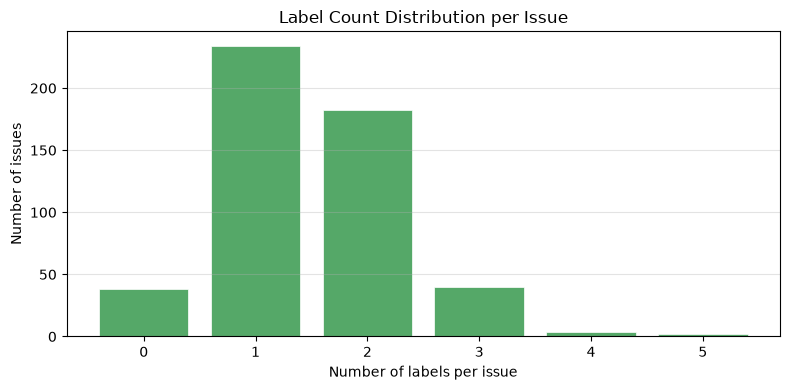

[OK] Figure saved: labels_per_issue_distribution.png


In [6]:
lpi_counter = Counter(lpi)
max_lbl = max(lpi_counter)
x = list(range(max_lbl + 1))
y = [lpi_counter.get(i, 0) for i in x]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, y, color="#55A868", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of labels per issue")
ax.set_ylabel("Number of issues")
ax.set_title("Label Count Distribution per Issue")
ax.set_xticks(x)
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "labels_per_issue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Figure saved: labels_per_issue_distribution.png")

## 5. Text-Length Analysis

Short issues may not contain enough information for the model to classify
them reliably.  Very long issues (e.g. with large stack traces) may require
truncation.

We measure title, body, and combined character lengths.

In [7]:
lengths = compute_text_lengths(issues)

for key in ("title", "body", "combined"):
    desc = describe_lengths(lengths[key])
    zeros = sum(1 for v in lengths[key] if v == 0)
    print(f"── {key.upper()} ─────────────────────────────────────────────")
    print(f"  min={int(desc['min'])}  "
          f"median={int(desc['median'])}  "
          f"mean={desc['mean']:.0f}  "
          f"p95={int(desc['p95'])}  "
          f"max={int(desc['max'])}")
    print(f"  Zero-length  : {zeros}")
    print()

── TITLE ─────────────────────────────────────────────
  min=8  median=71  mean=71  p95=111  max=168
  Zero-length  : 0

── BODY ─────────────────────────────────────────────
  min=0  median=1694  mean=2426  p95=6565  max=56428
  Zero-length  : 1

── COMBINED ─────────────────────────────────────────────
  min=13  median=1766  mean=2497  p95=6631  max=56563
  Zero-length  : 0



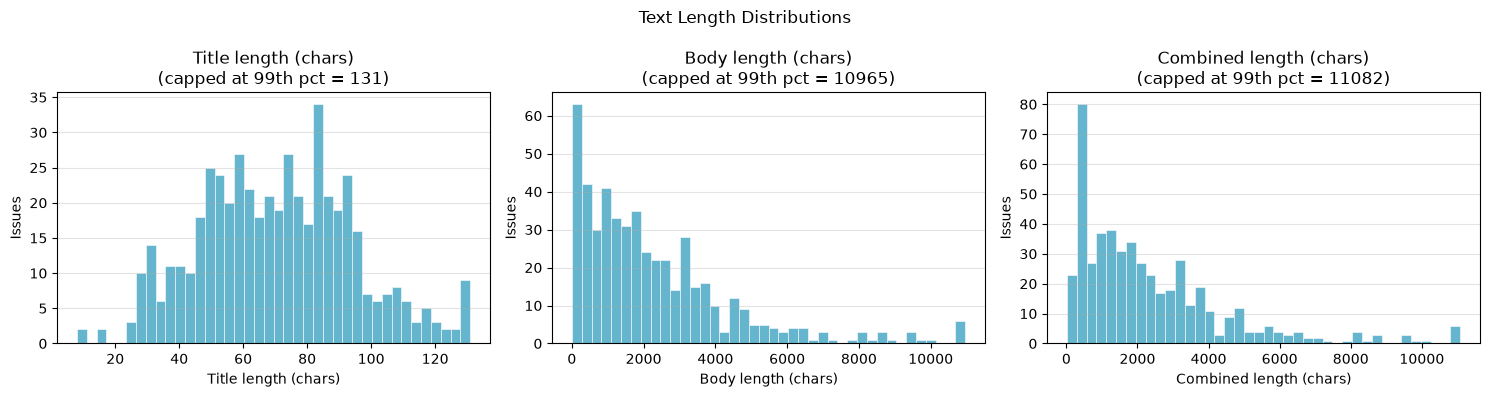

[OK] Figure saved: text_length_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels_map = {
    "title":    "Title length (chars)",
    "body":     "Body length (chars)",
    "combined": "Combined length (chars)",
}
for ax, key in zip(axes, ["title", "body", "combined"]):
    data = lengths[key]
    cap  = int(np.percentile(data, 99))
    clipped = [min(v, cap) for v in data]
    ax.hist(clipped, bins=40, color="#64B5CD", edgecolor="white", linewidth=0.4)
    ax.set_xlabel(labels_map[key])
    ax.set_ylabel("Issues")
    ax.set_title(f"{labels_map[key]}\n(capped at 99th pct = {cap})")
    ax.grid(axis="y", alpha=0.35)

fig.suptitle("Text Length Distributions", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Figure saved: text_length_distribution.png")

## 6. Label-Frequency Analysis

We count how often each label name appears across all 500 issues.
Many labels are *workflow* labels (e.g. "Needs Triage") or *component*
labels (e.g. "Array API") rather than issue-type labels.

Separating these roles is essential: we only want *issue-type* labels as
prediction targets.

In [9]:
freq = compute_label_frequencies(issues)
print(f"Total unique labels: {len(freq)}")
print()
print(f"{'Rank':<6} {'Label':<45} {'Count':>6}")
print("-" * 58)
for rank, (label, cnt) in enumerate(freq.most_common(30), 1):
    print(f"{rank:<6} {label:<45} {cnt:>6}")

Total unique labels: 59

Rank   Label                                          Count
----------------------------------------------------------
1      Bug                                              165
2      Needs Triage                                     105
3      Documentation                                     71
4      New Feature                                       57
5      Array API                                         37
6      Build / CI                                        32
7      RFC                                               28
8      Needs Decision                                    25
9      Callbacks                                         22
10     Needs Investigation                               18
11     module:test-suite                                 10
12     free-threading                                    10
13     frontend                                           9
14     API                                                9
15     Needs Dec

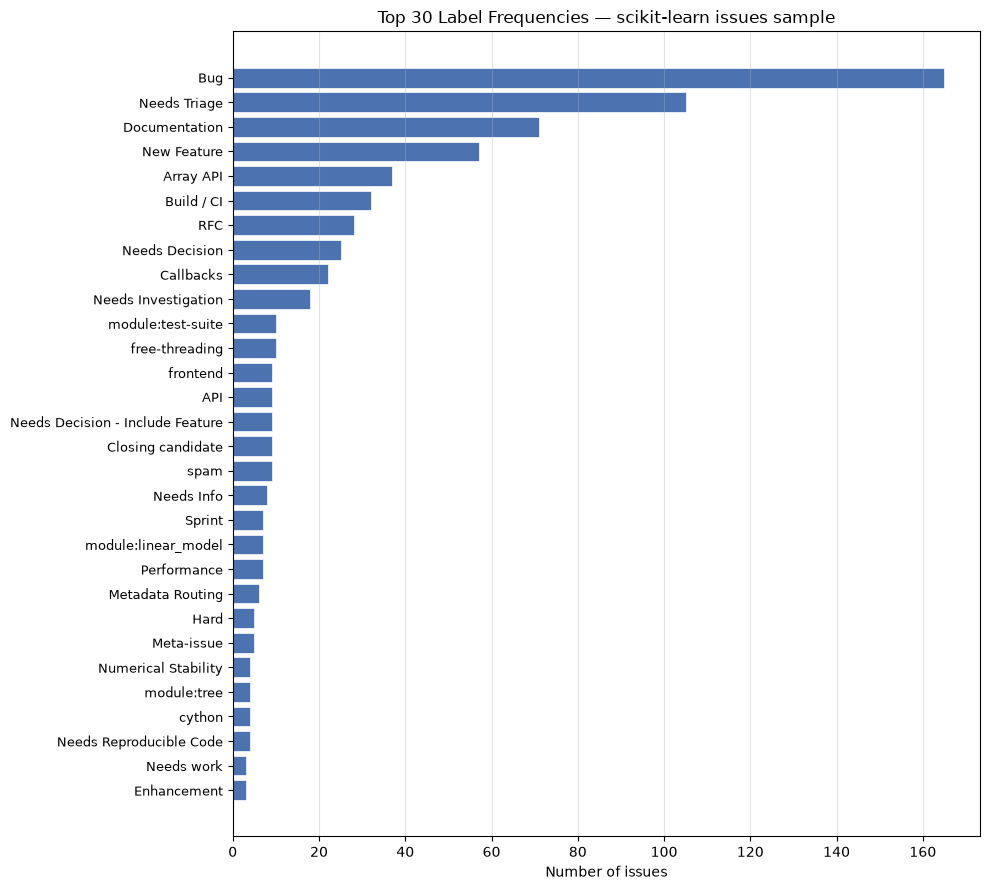

[OK] Figure saved: top_label_frequencies.png


In [10]:
top = freq.most_common(30)
top_labels, top_counts = zip(*top)

fig, ax = plt.subplots(figsize=(10, 9))
y = range(len(top_labels))
ax.barh(list(y), list(top_counts), color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(list(top_labels), fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of issues")
ax.set_title("Top 30 Label Frequencies — scikit-learn issues sample")
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "top_label_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Figure saved: top_label_frequencies.png")

### Label Role Classification (Provisional)

The following categorisation is **manually proposed** based on label names
and knowledge of scikit-learn's GitHub conventions.  It must be reviewed
and revised before finalising the dataset design.

In [11]:
categories = categorize_labels_provisionally(freq)

for role, labels_in_role in categories.items():
    print(f"\n── {role.upper()} ────────────────────────────────────────────────")
    for lb in labels_in_role:
        cnt = freq.get(lb, 0)
        print(f"  {lb:<45} {cnt:>4} occurrences")


── TYPE ────────────────────────────────────────────────
  Bug                                            165 occurrences
  Documentation                                   71 occurrences
  New Feature                                     57 occurrences
  RFC                                             28 occurrences
  Build / CI                                      32 occurrences

── COMPONENT ────────────────────────────────────────────────
  Array API                                       37 occurrences
  Callbacks                                       22 occurrences
  module:test-suite                               10 occurrences
  free-threading                                  10 occurrences
  frontend                                         9 occurrences
  API                                              9 occurrences
  module:linear_model                              7 occurrences

── WORKFLOW ────────────────────────────────────────────────
  Needs Triage                       

## 7. Label Co-occurrence

Issues often carry multiple labels simultaneously.  Understanding which labels
appear together tells us:

1. Whether *type* labels (Bug, Documentation, …) tend to co-occur with each
   other (which would create ambiguity in our classification task).
2. Which *component* labels (Array API, Callbacks, …) are most commonly
   attached to issues of a particular type.

We visualise this as a heatmap for the top 20 labels.

In [12]:
top20_labels = [lb for lb, _ in freq.most_common(20)]
cooc = compute_label_cooccurrence(issues, selected_labels=top20_labels)

# Print the strongest co-occurring pairs
sorted_pairs = sorted(cooc.items(), key=lambda x: -x[1])
print(f"Top 20 label pairs by co-occurrence count:")
print(f"{'Label A':<35} {'Label B':<35} {'Count':>6}")
print("-" * 77)
for (la, lb), cnt in sorted_pairs[:20]:
    print(f"{la:<35} {lb:<35} {cnt:>6}")

Top 20 label pairs by co-occurrence count:
Label A                             Label B                              Count
-----------------------------------------------------------------------------
Bug                                 Needs Triage                            40
Needs Triage                        New Feature                             15
Bug                                 Needs Investigation                     12
Array API                           Bug                                     12
Documentation                       Needs Triage                            10
Needs Decision                      New Feature                             10
Needs Decision - Include Feature    New Feature                              9
Array API                           RFC                                      6
Closing candidate                   Documentation                            5
Bug                                 Build / CI                               5
Bug       

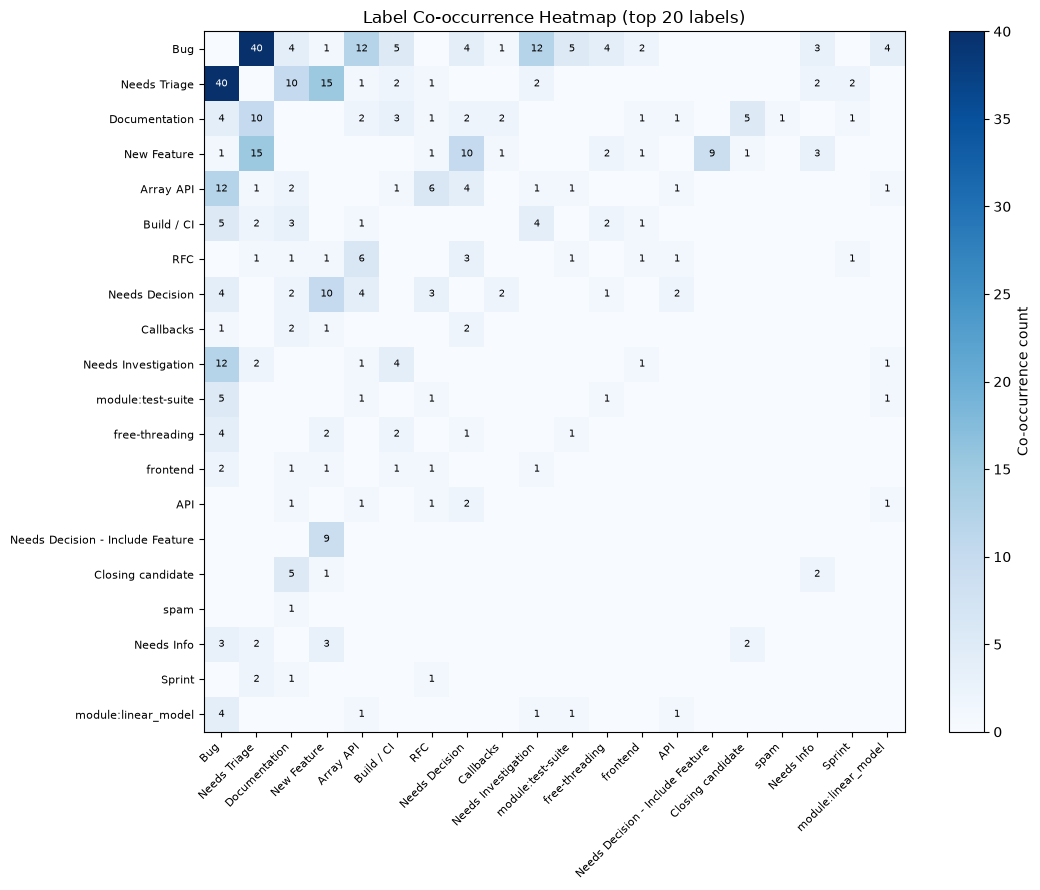

[OK] Figure saved: label_cooccurrence_heatmap.png


In [13]:
n = len(top20_labels)
matrix = np.zeros((n, n), dtype=int)
idx = {lb: i for i, lb in enumerate(top20_labels)}

for (la, lb), cnt in cooc.items():
    if la in idx and lb in idx:
        i, j = idx[la], idx[lb]
        matrix[i, j] = cnt
        matrix[j, i] = cnt

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(matrix, cmap="Blues", aspect="auto")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(top20_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(top20_labels, fontsize=8)

for i in range(n):
    for j in range(n):
        if matrix[i, j] > 0:
            text_color = "white" if matrix[i, j] > matrix.max() * 0.55 else "black"
            ax.text(j, i, str(matrix[i, j]),
                    ha="center", va="center", fontsize=7, color=text_color)

plt.colorbar(im, ax=ax, label="Co-occurrence count")
ax.set_title("Label Co-occurrence Heatmap (top 20 labels)")
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "label_cooccurrence_heatmap.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("[OK] Figure saved: label_cooccurrence_heatmap.png")

## 8. Temporal Analysis

Our 500 issues were collected with `state=all` and `page=1`, meaning the
GitHub API returned the **most recently created issues first**.
All 500 are drawn from approximately the last 10 months.

This creates **recency bias** — the label distribution of these issues may
not reflect the full history of the repository.  For example:

- The "Array API" integration (a major ongoing effort) accounts for 37 issues
  in this window but may be over-represented compared to historical norms.
- Newly emerging features ("Callbacks", "free-threading") are only visible
  in recent issues.

The temporal chart below shows how issues are distributed across months.

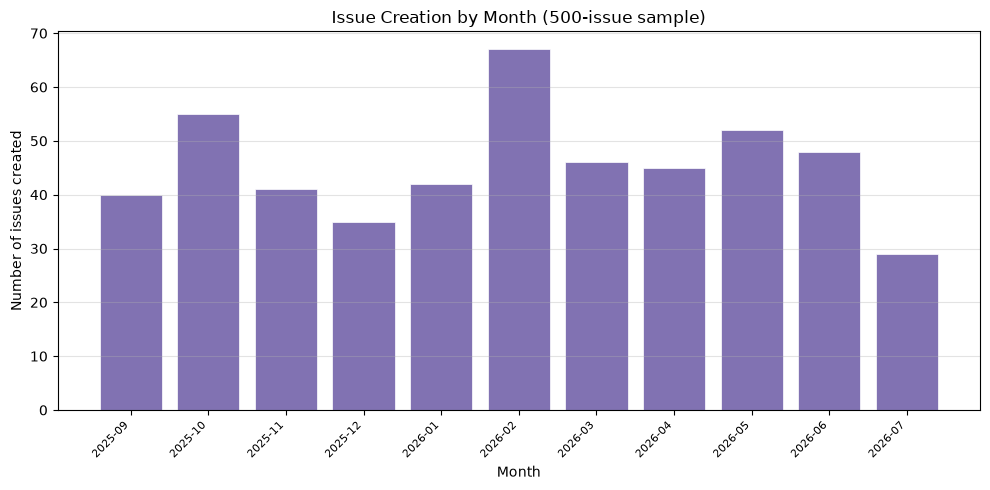

[OK] Figure saved: creation_dates_by_month.png

Monthly counts:
  2025-09:  40  ########################################
  2025-10:  55  #######################################################
  2025-11:  41  #########################################
  2025-12:  35  ###################################
  2026-01:  42  ##########################################
  2026-02:  67  ###################################################################
  2026-03:  46  ##############################################
  2026-04:  45  #############################################
  2026-05:  52  ####################################################
  2026-06:  48  ################################################
  2026-07:  29  #############################


In [14]:
monthly = compute_temporal_distribution(issues)
months  = sorted(monthly)
counts  = [monthly[m] for m in months]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(months, counts, color="#8172B2", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("Number of issues created")
ax.set_title("Issue Creation by Month (500-issue sample)")
ax.grid(axis="y", alpha=0.35)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "creation_dates_by_month.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Figure saved: creation_dates_by_month.png")

print()
print("Monthly counts:")
for m, c in zip(months, counts):
    bar = "#" * c
    print(f"  {m}: {c:>3}  {bar}")

## 9. Leakage Investigation

*Label leakage* occurs when the input features directly reveal the target
label.  For example, if a developer writes "BUG: output is NaN" in the title,
a model could classify the issue correctly just by recognising the prefix —
without learning any real patterns.

We check two forms of leakage:

1. **Prefix leakage** — titles beginning with patterns like `[BUG]`, `ENH:`,
   `[RFC]`, `CI:`, etc.
2. **Literal label in title** — any provisional type label name (e.g. "bug",
   "documentation") appearing verbatim in the title text.

In [15]:
leakage = detect_leakage(issues)
prefix_issues = leakage["prefix_matches"]
label_issues  = leakage["label_in_title"]

print(f"Prefixes checked     : {LEAKAGE_PREFIXES}")
print(f"Type labels checked  : {sorted(PROVISIONAL_TYPE_LABELS)}")
print()
print(f"Titles with a prefix : {len(prefix_issues)}  ({100*len(prefix_issues)/total:.1f}%)")
print(f"Titles with label name: {len(label_issues)}  ({100*len(label_issues)/total:.1f}%)")

# Show a sample of flagged titles
prefix_set = set(prefix_issues)
sample_titles = [(i["number"], i["title"]) for i in issues if i["number"] in prefix_set][:8]
print()
print("Sample of prefix-flagged titles:")
for num, title in sample_titles:
    print(f"  #{num}: {title[:75]}")

Prefixes checked     : ['BUG', 'DOC', 'ENH', 'FEATURE', 'RFC', 'CI', 'FIX', 'MAINT', 'TST']
Type labels checked  : ['Bug', 'Build / CI', 'Documentation', 'New Feature', 'RFC']

Titles with a prefix : 120  (24.0%)
Titles with label name: 79  (15.8%)

Sample of prefix-flagged titles:
  #34542: CI Pyodide failure `RuntimeError: can't start new thread`
  #34537: RFC Remove possibly unused extra_requires i.e. `pip install scikit-learn[yo
  #34521: Doc CI failure due to seaborn bug
  #34489: RFC Licencing issues when contributors had sold their copyright to paid pla
  #34459: DOC: clarify n_iter_ can be 0 when warm_start=True in LogisticRegression
  #34454: [DOC] Improve docstring for `orthogonal_mp`
  #34414: MAINT - Remove Sass dependency
  #34401: DOC: fix typo and inconsistencies in RidgeClassifier docstrings


In [16]:
# Cross-tabulate prefix-flagged issues by their type labels
prefix_set    = set(prefix_issues)
flagged_types = Counter()
for issue in issues:
    if issue["number"] in prefix_set:
        for lb in (issue.get("labels") or []):
            if lb in PROVISIONAL_TYPE_LABELS:
                flagged_types[lb] += 1

print("Type labels on prefix-flagged issues:")
for lb, cnt in flagged_types.most_common():
    print(f"  {lb:<25} {cnt}")

print()
print("Interpretation:")
print(f"  {len(prefix_issues)} out of {total} titles ({100*len(prefix_issues)/total:.1f}%)")
print("  carry a category prefix. This is moderate leakage risk.")
print("  A baseline model could exploit these prefixes without learning")
print("  any real semantic content. We will need to:")
print("  (a) record this as a known data-quality issue, and")
print("  (b) evaluate model performance on prefix-free issues separately.")

Type labels on prefix-flagged issues:
  Documentation             31
  Bug                       26
  RFC                       25
  Build / CI                12
  New Feature               11

Interpretation:
  120 out of 500 titles (24.0%)
  carry a category prefix. This is moderate leakage risk.
  A baseline model could exploit these prefixes without learning
  any real semantic content. We will need to:
  (a) record this as a known data-quality issue, and
  (b) evaluate model performance on prefix-free issues separately.


## 10. Provisional Issue-Type Subset

We now build the clean subset of issues that have **exactly one** of the
five provisional type labels.  Issues with zero or multiple type labels are
excluded.

- **Zero type labels** → excluded (no learning signal for our task).
- **Multiple type labels** → excluded (ambiguous ground truth).

This gives us the maximum number of cleanly labelled examples we can use
for a first model, and shows the class balance problem we must address.

In [17]:
result = build_provisional_subset(issues)

print(f"Total issues             : {total}")
print(f"Usable (1 type label)    : {result['total_usable']}  ({100*result['total_usable']/total:.1f}%)")
print(f"Excluded (no type label) : {result['excluded_unlabelled']}")
print(f"Excluded (multi-type)    : {result['excluded_multi_type']}")
print()
print("── Class counts ──────────────────────────────────────────────────")
for label, cnt in sorted(result["class_counts"].items(), key=lambda x: -x[1]):
    pct = 100 * cnt / result["total_usable"]
    bar = "#" * int(pct / 2)
    print(f"  {label:<25} {cnt:>4}  ({pct:>5.1f}%)  {bar}")

print()
print("── Multi-type overlaps ───────────────────────────────────────────")
print(f"  {result['excluded_multi_type']} issues carry two or more type labels:")
for num, labels_on_issue in result["type_label_overlap"][:10]:
    print(f"  #{num}: {labels_on_issue}")

Total issues             : 500
Usable (1 type label)    : 326  (65.2%)
Excluded (no type label) : 161
Excluded (multi-type)    : 13

── Class counts ──────────────────────────────────────────────────
  Bug                        156  ( 47.9%)  #######################
  Documentation               64  ( 19.6%)  #########
  New Feature                 55  ( 16.9%)  ########
  RFC                         26  (  8.0%)  ###
  Build / CI                  25  (  7.7%)  ###

── Multi-type overlaps ───────────────────────────────────────────
  13 issues carry two or more type labels:
  #34521: ['Build / CI', 'Documentation']
  #34254: ['Build / CI', 'Documentation']
  #33840: ['Bug', 'Documentation']
  #33510: ['Bug', 'Build / CI']
  #33412: ['New Feature', 'RFC']
  #33231: ['Bug', 'Documentation']
  #33174: ['Bug', 'Build / CI']
  #33112: ['Bug', 'Documentation']
  #33075: ['Bug', 'Build / CI']
  #32833: ['Bug', 'Build / CI', 'Documentation']


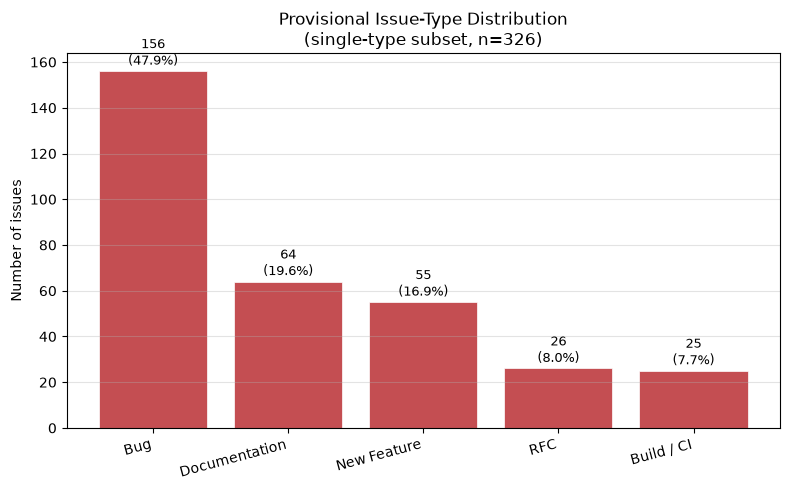

[OK] Figure saved: type_label_distribution.png


In [18]:
items  = sorted(result["class_counts"].items(), key=lambda x: -x[1])
labels_plot, counts_plot = zip(*items)
total_usable = result["total_usable"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    labels_plot, counts_plot, color="#C44E52", edgecolor="white", linewidth=0.5
)
for bar, cnt in zip(bars, counts_plot):
    pct = 100 * cnt / total_usable
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{cnt}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_ylabel("Number of issues")
ax.set_title("Provisional Issue-Type Distribution\n(single-type subset, n=326)")
ax.grid(axis="y", alpha=0.35)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "type_label_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("[OK] Figure saved: type_label_distribution.png")

## 11. Limitations

> **These limitations must be addressed before the dataset is used for
> model training.**

### 11.1 Recency bias

All 500 issues come from approximately the last 10 months (2025-09-10 to
2026-07-22).  The label distribution in this window may not match the
overall history of the repository.  In particular:

- Labels for newer scikit-learn sub-projects ("Array API", "Callbacks",
  "free-threading") are heavily represented.
- Older, more established label patterns may be under-represented.

### 11.2 Small sample size

326 clean single-type issues is sufficient for a first experiment, but:

- **Bug dominates**: 156/326 (47.9%) of examples are bugs.  The smallest
  class (Build / CI, 25 examples) has fewer than 1/6 as many.
- Training a fair multi-class classifier on 25 examples of one class is
  very difficult without either balancing or collecting more data.

### 11.3 Moderate leakage risk

120 out of 500 titles (24%) carry a category prefix (e.g. `[BUG]`, `ENH:`).
This is a significant potential data leak.  The model must be evaluated
separately on prefix-free issues.

### 11.4 Provisional label scheme

The five type labels were chosen based on what appeared in this small sample.
The full scikit-learn issue history likely contains additional patterns.
The label scheme should be validated against a larger historical sample before
being treated as final.

### 11.5 Missing body

1 issue has an empty body.  This will produce a zero-length combined text.
Edge cases like this must be handled explicitly in the preprocessing pipeline.

## 12. Recommendation for the Next Collection Stage

Based on this audit, we recommend the following before proceeding to
Stage 2 (preprocessing and modelling):

---

### Recommendation A — Collect more historical scikit-learn issues

**Reason:** The current sample is too small and too recent.  The class
imbalance (Bug: 47.9%, Build / CI: 7.7%) is likely to produce a biased model.

**Action:** Re-run the collector with a much larger `--max-issues` limit
(e.g. 3,000–5,000) to obtain a more representative sample spanning
several years of the repository's history.

---

### Recommendation B — Separate issue-type from component prediction

**Reason:** The audit reveals two clearly different label roles:
- **Type labels** (Bug, Documentation, …) describe *what kind* of problem it is.
- **Component labels** (Array API, Callbacks, …) describe *where* the problem is.

**Action:** Design two separate classification tasks:
1. Task 1: Predict issue type (Bug / Documentation / Feature / RFC / Build).
2. Task 2: Predict affected component (Array API / linear_model / test-suite …).

---

### Recommendation C — Address the leakage risk explicitly

**Reason:** 24% of titles carry a category prefix that directly reveals the label.

**Action:**
1. Strip known prefixes from titles in the preprocessing step.
2. Evaluate the final model both on the full dataset and on the
   prefix-free subset to quantify the leakage effect.

---

### Recommendation D — Validate the label scheme on older issues

**Reason:** The current five labels are based on a 10-month sample.

**Action:** After collecting 3,000+ issues, re-run this audit notebook to
check whether the same five labels cover the majority of clearly labelled
issues, or whether additional categories are needed.

---

*This notebook was produced as part of Stage 1B of the GitHub Issue
Intelligence project (ML university course, 2026).*

In [19]:
print("=" * 60)
print("  AUDIT COMPLETE — KEY NUMBERS")
print("=" * 60)
print(f"  Total issues          : {total}")
print(f"  With labels           : {with_labels}  ({100*with_labels/total:.1f}%)")
print(f"  Multi-label issues    : {multi_label}  ({100*multi_label/total:.1f}%)")
print(f"  Unique label names    : {len(freq)}")
print(f"  Leakage-prefix titles : {len(prefix_issues)}  ({100*len(prefix_issues)/total:.1f}%)")
print(f"  Usable (single-type)  : {result['total_usable']}  ({100*result['total_usable']/total:.1f}%)")
print()
print("  Class breakdown (provisional subset):")
for lbl, cnt in sorted(result['class_counts'].items(), key=lambda x: -x[1]):
    pct = 100 * cnt / result["total_usable"]
    print(f"    {lbl:<25} {cnt:>4}  ({pct:.1f}%)")
print()
print("  Figures saved to:", FIGURES_DIR)
print("=" * 60)

  AUDIT COMPLETE — KEY NUMBERS
  Total issues          : 500
  With labels           : 462  (92.4%)
  Multi-label issues    : 228  (45.6%)
  Unique label names    : 59
  Leakage-prefix titles : 120  (24.0%)
  Usable (single-type)  : 326  (65.2%)

  Class breakdown (provisional subset):
    Bug                        156  (47.9%)
    Documentation               64  (19.6%)
    New Feature                 55  (16.9%)
    RFC                         26  (8.0%)
    Build / CI                  25  (7.7%)

  Figures saved to: C:\Users\Nips\Desktop\github-issue-intelligence\reports\figures
